# 20 · Paired specification-grid sensitivity — Gate 21

**Purpose.** Test whether metropolitan amplification of the female-minus-male FPT gap persists when the opportunity-set definition and residential conditioning rule are changed.

The point-estimate grid crosses:

- `core_50` and `extended_80` scope-specific destination sets;
- `outside_target` and `all_residences` aggregation;
- Bogotá D.C. internal and the complete Bogotá–Region system.

The full-population reference kernel and $\tau=20$ are held fixed. The practically redundant `valid sex` reference is not repeated: Gate 10 showed that valid-sex coverage is nearly complete and that this alternative differs only below the reported precision. The primary specification remains `core_50 + outside_target`; this gate is a point-estimate sensitivity analysis and does not reuse its confidence intervals for alternative specifications.


In [1]:
%pip -q install pandas pyarrow numpy scipy matplotlib seaborn geopandas networkx


In [2]:
from pathlib import Path
from datetime import datetime, timezone
import csv
import hashlib
import json
import os
import re
import shutil
import unicodedata
import zipfile

import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path("/content/colombia-stochastic-access")
RAW = ROOT / "data/raw/bogota_em2023"
INTERIM = ROOT / "data/interim/bogota_em2023_gate21"
OUT = ROOT / "outputs/bogota_em2023/gate21"
DRIVE_BASE = Path("/content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023")
for directory in (RAW, INTERIM, OUT):
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_URL = "https://observatorio.movilidadbogota.gov.co/sites/default/files/2025-09/05_Base%20datos%20procesada%20EODH.zip"
ZONING_URL = "https://observatorio.movilidadbogota.gov.co/sites/default/files/2025-09/03_Zonificacion%20EODH%20%281%29.zip"
PURPOSES = ("employment", "education", "health")
TARGET_DEFINITIONS = ("core_50", "extended_80")
TARGET_THRESHOLDS = {"core_50": 0.50, "extended_80": 0.80}
CONDITIONING_MODES = ("outside_target", "all_residences")
EFFECTS = ("female_minus_male_total", "residential_contribution", "kernel_contribution")
PRIMARY_TAU = 20.0
MIN_DESTINATION_SAMPLE = 5
MIN_DESTINATION_ESS = 3.0

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Environment outside Colab or Drive not mounted: {exc}")

G10 = Path(os.environ.get("GATE10_DIR_OVERRIDE", DRIVE_BASE / "results/gate10"))
G12 = Path(os.environ.get("GATE12_DIR_OVERRIDE", DRIVE_BASE / "results/gate12"))
paths = {
    "gate10": G10 / "gate_10.json",
    "region_grid": G10 / "robustness_female_male_point_estimates.csv",
    "gate12": G12 / "gate_12.json",
    "city_primary": G12 / "bogota_dc_internal_female_male_point_estimates.csv",
    "city_core_targets": G12 / "bogota_dc_internal_core50_targets.csv",
}
missing = [str(path) for path in paths.values() if not path.exists()]
if missing:
    raise FileNotFoundError("Missing validated inputs: " + ", ".join(missing))

gate10 = json.loads(paths["gate10"].read_text(encoding="utf-8"))
gate12 = json.loads(paths["gate12"].read_text(encoding="utf-8"))
gate10_status = gate10.get("gate", gate10)
gate12_status = gate12.get("gate", gate12)
if not bool(gate10_status.get("gate_10_passed", False)):
    raise RuntimeError("Gate 10 is not approved")
if not bool(gate12_status.get("gate_12_passed", False)):
    raise RuntimeError("Gate 12 is not approved")

print("Validated dependencies: Gates 10 and 12")
print("Specifications:", len(TARGET_DEFINITIONS) * len(CONDITIONING_MODES))
print("Output:", OUT)


Mounted at /content/drive
Validated dependencies: Gates 10 and 12
Specifications: 4
Output: /content/colombia-stochastic-access/outputs/bogota_em2023/gate21


In [3]:
def sha256(path, chunk_size=1024 * 1024):
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for chunk in iter(lambda: handle.read(chunk_size), b""):
            digest.update(chunk)
    return digest.hexdigest()


def valid_zip(path):
    path = Path(path)
    return path.exists() and path.stat().st_size > 0 and zipfile.is_zipfile(path)


def upload_archive(destination, url, label):
    from google.colab import files
    print(f"Descargue y seleccione el ZIP de {label}:")
    print(url)
    uploaded = files.upload()
    if len(uploaded) != 1:
        raise ValueError("Suba exactamente un archivo ZIP.")
    name, content = next(iter(uploaded.items()))
    temporary = destination.with_suffix(".zip.upload")
    temporary.write_bytes(content)
    del content
    if not valid_zip(temporary):
        temporary.unlink(missing_ok=True)
        raise ValueError(f"{name} no es un ZIP válido.")
    temporary.replace(destination)
    return "manual_upload"


def ensure_archive(runtime_name, drive_name, url, label):
    runtime = RAW / runtime_name
    cached = DRIVE_BASE / drive_name
    if valid_zip(runtime):
        method = "runtime_cache"
    elif valid_zip(cached):
        shutil.copy2(cached, runtime)
        method = "google_drive_cache"
    else:
        method = upload_archive(runtime, url, label)
        DRIVE_BASE.mkdir(parents=True, exist_ok=True)
        shutil.copy2(runtime, cached)
    return runtime, method


def safe_extract_recursive(zip_path, destination):
    destination.mkdir(parents=True, exist_ok=True)
    queue = [(Path(zip_path), destination)]
    visited = set()
    while queue:
        current, target = queue.pop(0)
        signature = (str(current.resolve()), str(target.resolve()))
        if signature in visited:
            continue
        visited.add(signature)
        root = target.resolve()
        with zipfile.ZipFile(current) as zipped:
            for member in zipped.infolist():
                resolved = (target / member.filename).resolve()
                if root != resolved and root not in resolved.parents:
                    raise ValueError(f"Ruta insegura en ZIP: {member.filename}")
            zipped.extractall(target)
        for nested in target.rglob("*.zip"):
            nested_target = nested.parent / nested.stem
            nested_signature = (str(nested.resolve()), str(nested_target.resolve()))
            if nested_signature not in visited:
                queue.append((nested, nested_target))


survey_archive, survey_method = ensure_archive(
    "processed_edoh.zip", "processed_edoh.zip", SOURCE_URL, "microdatos procesados"
)
zoning_archive, zoning_method = ensure_archive(
    "zoning_edoh.zip", "zoning_edoh.zip", ZONING_URL, "zonificación"
)
safe_extract_recursive(survey_archive, INTERIM / "processed_edoh")
safe_extract_recursive(zoning_archive, INTERIM / "zoning_edoh")

source_manifest = pd.DataFrame([
    {"source_id": "processed_edoh", "url": SOURCE_URL, "path": str(survey_archive),
     "bytes": int(survey_archive.stat().st_size), "sha256": sha256(survey_archive),
     "retrieval_method": survey_method},
    {"source_id": "zoning_edoh", "url": ZONING_URL, "path": str(zoning_archive),
     "bytes": int(zoning_archive.stat().st_size), "sha256": sha256(zoning_archive),
     "retrieval_method": zoning_method},
])
source_manifest["generated_utc"] = datetime.now(timezone.utc).isoformat()
source_manifest.to_csv(OUT / "source_manifest.csv", index=False)
display(source_manifest)


,source_id,url,path,bytes,sha256,retrieval_method,generated_utc
0,processed_edoh,https://observatorio.movilidadbogota.gov.co/si...,/content/colombia-stochastic-access/data/raw/b...,88826883,2509410f39713de4768872952e75e95809a99d7edf5b65...,google_drive_cache,2026-09-20T10:49:37.985237+00:00
1,zoning_edoh,https://observatorio.movilidadbogota.gov.co/si...,/content/colombia-stochastic-access/data/raw/b...,12225582,405ef62643663e656f58b0595a90a873029809e0aab430...,google_drive_cache,2026-09-20T10:49:37.985237+00:00


In [4]:
def normalize(value):
    value = unicodedata.normalize("NFKD", str(value))
    value = "".join(char for char in value if not unicodedata.combining(char))
    return re.sub(r"[^a-z0-9]+", "_", value.lower().strip()).strip("_")


def clean_key(series):
    cleaned = series.astype("string").str.strip().str.replace(r"\.0$", "", regex=True)
    invalid = cleaned.map(normalize).isin(["", "nan", "none", "na", "no_aplica", "sin_informacion"])
    return cleaned.mask(invalid)


def canonical_utam(series):
    cleaned = clean_key(series)
    def canonical(value):
        if pd.isna(value):
            return pd.NA
        text = str(value).strip().upper().replace(" ", "")
        upr = re.fullmatch(r"UPR0*(\d+)", text)
        if upr:
            return f"UPR{int(upr.group(1)):04d}"
        utam = re.fullmatch(r"(?:UTAM)?0*(\d+)", text)
        if utam:
            return f"UTAM{int(utam.group(1)):03d}"
        return text
    return cleaned.map(canonical).astype("string")


def parse_number(series):
    raw = series.astype("string").str.strip()
    if float(raw.str.contains(",", regex=False, na=False).mean()) > 0.05:
        raw = raw.str.replace(".", "", regex=False).str.replace(",", ".", regex=False)
    return pd.to_numeric(raw, errors="coerce")


def csv_format(path):
    for encoding in ("utf-8-sig", "latin-1"):
        try:
            with path.open("r", encoding=encoding, errors="strict") as handle:
                sample = handle.read(32768)
            return encoding, csv.Sniffer().sniff(sample, delimiters=",;\t|").delimiter
        except (UnicodeDecodeError, csv.Error):
            continue
    raise ValueError(f"No fue posible detectar el formato: {path}")


def find_module(token, excluded=()):
    candidates = [
        path for path in (INTERIM / "processed_edoh").rglob("*.csv")
        if token in normalize(path.stem)
        and not any(item in normalize(path.stem) for item in excluded)
    ]
    if not candidates:
        raise FileNotFoundError(f"No se encontró el módulo CSV: {token}")
    return sorted(candidates, key=lambda path: (len(path.parts), len(path.name)))[0]


def read_selected(path, required):
    encoding, delimiter = csv_format(path)
    header = pd.read_csv(path, sep=delimiter, encoding=encoding, nrows=0)
    mapping = {normalize(column): column for column in header.columns}
    absent = sorted(set(required) - set(mapping))
    if absent:
        raise KeyError(f"Faltan columnas en {path.name}: {absent}")
    frame = pd.read_csv(path, sep=delimiter, encoding=encoding,
                        usecols=[mapping[column] for column in required],
                        dtype="string", low_memory=False)
    frame.columns = [normalize(column) for column in frame.columns]
    return frame


trips = read_selected(
    find_module("viaje", excluded=("etapa",)),
    ["key_hg", "utam_ori", "utam_des", "fexp_vj", "sexo", "motivo_viaje"],
)
persons = read_selected(
    find_module("persona"),
    ["key_hg", "cod_utam_hg", "fexp_per_5anos", "sexo"],
)
trips["household"] = clean_key(trips["key_hg"])
trips["utam_ori"] = canonical_utam(trips["utam_ori"])
trips["utam_des"] = canonical_utam(trips["utam_des"])
trips["weight"] = parse_number(trips["fexp_vj"])
trips["sex_group"] = trips["sexo"].map(normalize)
trips["purpose_normalized"] = trips["motivo_viaje"].map(normalize)
persons["household"] = clean_key(persons["key_hg"])
persons["residence_utam"] = canonical_utam(persons["cod_utam_hg"])
persons["weight"] = parse_number(persons["fexp_per_5anos"])
persons["sex_group"] = persons["sexo"].map(normalize)
trips = trips[
    trips[["household", "utam_ori", "utam_des"]].notna().all(axis=1)
    & trips["weight"].gt(0)
].reset_index(drop=True)
persons = persons[
    persons[["household", "residence_utam"]].notna().all(axis=1)
    & persons["weight"].gt(0)
].reset_index(drop=True)

PURPOSE_PATTERNS = {
    "employment": r"^a_trabajar$",
    "education": r"estudi|educa|coleg|univers|jardin|escuela",
    "health": r"salud|medic|hospital|clinic|consulta|terapia",
    "job_search": r"buscar_trabajo",
    "mobile_work": r"conduzco_vehiculo_como_forma_de_trabajo",
}
def classify_purpose(value):
    matches = [purpose for purpose, pattern in PURPOSE_PATTERNS.items() if re.search(pattern, value)]
    return "ambiguous" if len(matches) > 1 else (matches[0] if matches else "other")
trips["purpose_group"] = trips["purpose_normalized"].map(classify_purpose)

spatial_paths = sorted(
    list((INTERIM / "zoning_edoh").rglob("*.shp"))
    + list((INTERIM / "zoning_edoh").rglob("*.geojson"))
    + list((INTERIM / "zoning_edoh").rglob("*.gpkg"))
)
candidates = []
for path in spatial_paths:
    try:
        preview = gpd.read_file(path, rows=5)
        columns = {normalize(column): column for column in preview.columns}
        if "utam" in columns:
            candidates.append(path)
    except Exception:
        continue
if not candidates:
    raise FileNotFoundError("No se encontró capa espacial UTAM.")
utam_path = sorted(candidates, key=lambda path: ("utam2023" not in normalize(path.stem), len(path.parts)))[0]
utam_raw = gpd.read_file(utam_path)
column_map = {normalize(column): column for column in utam_raw.columns}
municipality_key = "munnombre" if "munnombre" in column_map else next(
    (key for key in column_map if "mun" in key and "nombre" in key), None
)
if municipality_key is None:
    raise KeyError("La capa UTAM no contiene nombre de municipio.")
utam_lookup = pd.DataFrame({
    "utam": canonical_utam(utam_raw[column_map["utam"]]),
    "municipality": utam_raw[column_map[municipality_key]].astype("string").str.strip(),
}).dropna(subset=["utam", "municipality"]).drop_duplicates("utam")
utam_lookup["municipality_normalized"] = utam_lookup["municipality"].map(normalize)
city_all_nodes = set(utam_lookup.loc[
    utam_lookup["municipality_normalized"].str.contains("bogota", na=False), "utam"
])
print("UTAM identificadas como Bogotá D. C.:", len(city_all_nodes))
print("Capa:", utam_path)


UTAM identificadas como Bogotá D. C.: 116
Capa: /content/colombia-stochastic-access/data/interim/bogota_em2023_gate21/zoning_edoh/03_Zonificacion EODH/a. Shapefile UTAM/UTAM2023/UTAM2023.shp


## District network and scope-specific target sets

The Bogotá D.C. kernel is reconstructed on its largest directed strongly connected component. Both destination definitions use the same minimum support rules as the primary analysis.


In [5]:
city_trips_all = trips[
    trips["utam_ori"].isin(city_all_nodes) & trips["utam_des"].isin(city_all_nodes)
].copy()
city_persons_all = persons[persons["residence_utam"].isin(city_all_nodes)].copy()

graph = nx.DiGraph()
edge_pairs = city_trips_all.groupby(
    ["utam_ori", "utam_des"], observed=True
)["weight"].sum()
graph.add_weighted_edges_from(
    (origin, destination, float(weight))
    for (origin, destination), weight in edge_pairs.items()
)
components = sorted(nx.strongly_connected_components(graph), key=len, reverse=True)
if not components:
    raise RuntimeError("The district network has no strongly connected component")
city_nodes_set = set(components[0])
city_nodes = sorted(city_nodes_set)
node_to_index = {node: index for index, node in enumerate(city_nodes)}
n_nodes = len(city_nodes)

city_trips = city_trips_all[
    city_trips_all["utam_ori"].isin(city_nodes_set)
    & city_trips_all["utam_des"].isin(city_nodes_set)
].reset_index(drop=True)
city_persons = city_persons_all[
    city_persons_all["residence_utam"].isin(city_nodes_set)
].reset_index(drop=True)

origin_index = city_trips["utam_ori"].map(node_to_index).to_numpy(dtype=int)
destination_index = city_trips["utam_des"].map(node_to_index).to_numpy(dtype=int)
base_trip_weight = city_trips["weight"].to_numpy(dtype=float)
residence_index = city_persons["residence_utam"].map(node_to_index).to_numpy(dtype=int)
base_person_weight = city_persons["weight"].to_numpy(dtype=float)

W0 = np.zeros((n_nodes, n_nodes), dtype=float)
np.add.at(W0, (origin_index, destination_index), base_trip_weight)
row_sum = W0.sum(axis=1)
if np.any(row_sum <= 0):
    raise RuntimeError("The district SCC contains an empty outgoing row")
P0 = W0 / row_sum[:, None]

purpose_trips = city_trips[city_trips["purpose_group"].isin(PURPOSES)].copy()
purpose_trips["weight_sq"] = purpose_trips["weight"] ** 2
support = purpose_trips.groupby(
    ["purpose_group", "utam_des"], observed=True
).agg(
    sampled_trips=("weight", "size"),
    weighted_trips=("weight", "sum"),
    sum_weight_sq=("weight_sq", "sum"),
).reset_index()
support["effective_sample_size"] = (
    support["weighted_trips"] ** 2
    / support["sum_weight_sq"].replace(0, np.nan)
)
support["supported"] = (
    support["sampled_trips"].ge(MIN_DESTINATION_SAMPLE)
    & support["effective_sample_size"].ge(MIN_DESTINATION_ESS)
)

target_sets = {}
target_rows = []
target_summary_rows = []
for purpose in PURPOSES:
    ranked = support[
        support["purpose_group"].eq(purpose) & support["supported"]
    ].sort_values(["weighted_trips", "utam_des"], ascending=[False, True]).copy()
    if ranked.empty:
        raise RuntimeError(f"No supported district destinations for {purpose}")
    ranked["rank"] = np.arange(1, len(ranked) + 1)
    ranked["cumulative_supported_share"] = (
        ranked["weighted_trips"].cumsum() / ranked["weighted_trips"].sum()
    )
    for definition, threshold in TARGET_THRESHOLDS.items():
        crossing = np.flatnonzero(
            ranked["cumulative_supported_share"].to_numpy() >= threshold
        )
        number = int(crossing[0] + 1) if len(crossing) else int(len(ranked))
        selected = ranked.head(number)
        target_sets[(purpose, definition)] = np.array(
            sorted(node_to_index[node] for node in selected["utam_des"]),
            dtype=int,
        )
        target_summary_rows.append({
            "scope": "bogota_dc_internal",
            "purpose_group": purpose,
            "target_definition": definition,
            "target_nodes": number,
            "selected_supported_share": float(
                selected["weighted_trips"].sum() / ranked["weighted_trips"].sum()
            ),
        })
        for row in selected.itertuples(index=False):
            target_rows.append({
                "purpose_group": purpose,
                "target_definition": definition,
                "utam": row.utam_des,
                "rank": int(row.rank),
                "weighted_trips": float(row.weighted_trips),
                "effective_sample_size": float(row.effective_sample_size),
                "cumulative_supported_share": float(row.cumulative_supported_share),
            })

city_targets = pd.DataFrame(target_rows)
city_target_summary = pd.DataFrame(target_summary_rows)
city_targets.to_csv(OUT / "district_scope_specific_targets.csv", index=False)
city_target_summary.to_csv(OUT / "district_target_summary.csv", index=False)

print("District nodes:", n_nodes)
display(city_target_summary)


District nodes: 114


,scope,purpose_group,target_definition,target_nodes,selected_supported_share
0,bogota_dc_internal,employment,core_50,24,0.500134
1,bogota_dc_internal,employment,extended_80,57,0.806320
2,bogota_dc_internal,education,core_50,24,0.512346
3,bogota_dc_internal,education,extended_80,55,0.806635
4,bogota_dc_internal,health,core_50,17,0.508305
5,bogota_dc_internal,health,extended_80,42,0.806424


## District specification grid


In [6]:
SEX_LEVELS = ("mujer", "hombre")

def sex_mask(frame, level):
    return frame["sex_group"].eq(level).fillna(False).to_numpy(dtype=bool)

trip_masks = {level: sex_mask(city_trips, level) for level in SEX_LEVELS}
person_masks = {level: sex_mask(city_persons, level) for level in SEX_LEVELS}

def regularized_kernel(mask):
    selected = np.flatnonzero(mask)
    weights = base_trip_weight[selected]
    origins = origin_index[selected]
    destinations = destination_index[selected]
    W = np.zeros((n_nodes, n_nodes), dtype=float)
    np.add.at(W, (origins, destinations), weights)
    out = W.sum(axis=1)
    sum_sq = np.bincount(
        origins, weights=weights ** 2, minlength=n_nodes
    )
    ess = np.divide(
        out ** 2, sum_sq, out=np.zeros(n_nodes), where=sum_sq > 0
    )
    empirical = np.zeros_like(W)
    observed = out > 0
    empirical[observed] = W[observed] / out[observed, None]
    omega = ess / (ess + PRIMARY_TAU)
    return omega[:, None] * empirical + (1.0 - omega[:, None]) * P0

def residential_distribution(mask):
    selected = np.flatnonzero(mask)
    mu = np.bincount(
        residence_index[selected],
        weights=base_person_weight[selected],
        minlength=n_nodes,
    ).astype(float)
    if not np.isfinite(mu).all() or mu.sum() <= 0:
        raise RuntimeError("Empty residential distribution")
    return mu / mu.sum()

def first_passage_by_origin(P, targets):
    target_mask = np.zeros(n_nodes, dtype=bool)
    target_mask[targets] = True
    transient = np.flatnonzero(~target_mask)
    Q = P[np.ix_(transient, transient)]
    h = np.zeros(n_nodes, dtype=float)
    h[transient] = np.linalg.solve(
        np.eye(len(transient)) - Q,
        np.ones(len(transient)),
    )
    return h

def aggregate_fpt(h, mu, targets, conditioning):
    if conditioning == "all_residences":
        return float(mu @ h)
    eligible = np.ones(n_nodes, dtype=bool)
    eligible[targets] = False
    mass = float(mu[eligible].sum())
    if mass <= 0:
        raise RuntimeError("Empty residential mass outside target")
    return float((mu[eligible] / mass) @ h[eligible])

def sex_gap_values(h_w, h_m, mu_w, mu_m, targets, conditioning):
    mm = aggregate_fpt(h_m, mu_m, targets, conditioning)
    mw = aggregate_fpt(h_m, mu_w, targets, conditioning)
    wm = aggregate_fpt(h_w, mu_m, targets, conditioning)
    ww = aggregate_fpt(h_w, mu_w, targets, conditioning)
    residence = 0.5 * ((mw - mm) + (ww - wm))
    kernel = 0.5 * ((wm - mm) + (ww - mw))
    total = ww - mm
    mean_level = 0.5 * (ww + mm)
    return {
        "male_total_fpt": mm,
        "female_total_fpt": ww,
        "female_minus_male_total": total,
        "residential_contribution": residence,
        "kernel_contribution": kernel,
        "relative_gap": total / mean_level,
        "closure_error": total - residence - kernel,
    }

kernels = {level: regularized_kernel(trip_masks[level]) for level in SEX_LEVELS}
mus = {
    level: residential_distribution(person_masks[level])
    for level in SEX_LEVELS
}

city_rows = []
for purpose in PURPOSES:
    for definition in TARGET_DEFINITIONS:
        targets = target_sets[(purpose, definition)]
        h_w = first_passage_by_origin(kernels["mujer"], targets)
        h_m = first_passage_by_origin(kernels["hombre"], targets)
        for conditioning in CONDITIONING_MODES:
            city_rows.append({
                "scope": "bogota_dc_internal",
                "reference_scheme": "full_population",
                "target_definition": definition,
                "conditioning": conditioning,
                "purpose_group": purpose,
                **sex_gap_values(
                    h_w, h_m, mus["mujer"], mus["hombre"],
                    targets, conditioning,
                ),
            })

city_grid = pd.DataFrame(city_rows)
city_grid.to_csv(OUT / "district_specification_grid.csv", index=False)
display(city_grid.round(4))


,scope,reference_scheme,target_definition,conditioning,purpose_group,male_total_fpt,female_total_fpt,female_minus_male_total,residential_contribution,kernel_contribution,relative_gap,closure_error
0,bogota_dc_internal,full_population,core_50,outside_target,employment,3.6156,4.0947,0.4790,-0.0104,0.4895,0.1243,0.0
1,bogota_dc_internal,full_population,core_50,all_residences,employment,2.8260,3.1814,0.3554,-0.0260,0.3814,0.1183,0.0
2,bogota_dc_internal,full_population,extended_80,outside_target,employment,2.0185,2.2874,0.2688,-0.0211,0.2900,0.1249,0.0
3,bogota_dc_internal,full_population,extended_80,all_residences,employment,0.8285,0.9222,0.0937,-0.0243,0.1180,0.1070,0.0
4,bogota_dc_internal,full_population,core_50,outside_target,education,3.7888,4.1874,0.3986,0.0099,0.3887,0.1000,0.0
5,bogota_dc_internal,full_population,core_50,all_residences,education,2.4513,2.7533,0.3020,0.0485,0.2536,0.1161,0.0
6,bogota_dc_internal,full_population,extended_80,outside_target,education,1.8770,1.9944,0.1175,-0.0030,0.1204,0.0607,0.0
7,bogota_dc_internal,full_population,extended_80,all_residences,education,0.5965,0.6524,0.0559,0.0171,0.0388,0.0895,0.0
8,bogota_dc_internal,full_population,core_50,outside_target,health,5.0448,5.2852,0.2405,-0.0011,0.2415,0.0466,0.0
9,bogota_dc_internal,full_population,core_50,all_residences,health,4.1383,4.3274,0.1892,-0.0088,0.1979,0.0447,0.0


## Paired Bogotá–Region minus Bogotá D.C. contrasts

Regional estimates are taken from the already validated Gate 10 grid and restricted to the full-population reference. Each regional specification is paired with the matching independently reconstructed district specification.


In [7]:
region_all = pd.read_csv(paths["region_grid"])
region_grid = region_all[
    region_all["reference_scheme"].eq("full_population")
].copy()
keys = [
    "reference_scheme", "target_definition",
    "conditioning", "purpose_group",
]
if region_grid.duplicated(keys).any():
    raise RuntimeError("Regional robustness rows are not unique")

region_grid["scope"] = "bogota_region"
region_grid["two_group_mean_fpt"] = (
    region_grid["female_total_fpt"] + region_grid["male_total_fpt"]
) / 2.0
region_grid["relative_gap"] = (
    region_grid["female_minus_male_total"]
    / region_grid["two_group_mean_fpt"]
)

paired = region_grid.merge(
    city_grid,
    on=keys,
    suffixes=("_region", "_district"),
    validate="one_to_one",
)
for effect in EFFECTS:
    paired[f"region_minus_district__{effect}"] = (
        paired[f"{effect}_region"] - paired[f"{effect}_district"]
    )
paired["region_minus_district__relative_gap"] = (
    paired["relative_gap_region"] - paired["relative_gap_district"]
)
paired["relative_gap_ratio_region_to_district"] = (
    paired["relative_gap_region"] / paired["relative_gap_district"]
)

output_columns = keys + [
    "female_minus_male_total_district",
    "female_minus_male_total_region",
    "region_minus_district__female_minus_male_total",
    "region_minus_district__residential_contribution",
    "region_minus_district__kernel_contribution",
    "relative_gap_district",
    "relative_gap_region",
    "region_minus_district__relative_gap",
    "relative_gap_ratio_region_to_district",
]
paired = paired[output_columns].sort_values(
    ["purpose_group", "target_definition", "conditioning"]
).reset_index(drop=True)
paired.to_csv(OUT / "paired_scope_specification_grid.csv", index=False)
display(paired.round(4))

summary = paired.groupby("purpose_group", observed=True).agg(
    minimum_scope_amplification=(
        "region_minus_district__female_minus_male_total", "min"
    ),
    maximum_scope_amplification=(
        "region_minus_district__female_minus_male_total", "max"
    ),
    minimum_kernel_amplification=(
        "region_minus_district__kernel_contribution", "min"
    ),
    maximum_kernel_amplification=(
        "region_minus_district__kernel_contribution", "max"
    ),
    minimum_relative_amplification=(
        "region_minus_district__relative_gap", "min"
    ),
    maximum_relative_amplification=(
        "region_minus_district__relative_gap", "max"
    ),
).reset_index()
summary.to_csv(OUT / "paired_scope_specification_ranges.csv", index=False)
display(summary.round(4))


,reference_scheme,target_definition,conditioning,purpose_group,female_minus_male_total_district,female_minus_male_total_region,region_minus_district__female_minus_male_total,region_minus_district__residential_contribution,region_minus_district__kernel_contribution,relative_gap_district,relative_gap_region,region_minus_district__relative_gap,relative_gap_ratio_region_to_district
0,full_population,core_50,all_residences,education,0.3020,0.5922,0.2902,-0.0186,0.3088,0.1161,0.1873,0.0712,1.6138
1,full_population,core_50,outside_target,education,0.3986,0.8274,0.4287,-0.0224,0.4511,0.1000,0.1753,0.0754,1.7540
2,full_population,extended_80,all_residences,education,0.0559,0.0902,0.0343,-0.0039,0.0382,0.0895,0.1346,0.0451,1.5038
3,full_population,extended_80,outside_target,education,0.1175,0.2388,0.1213,-0.0093,0.1306,0.0607,0.1095,0.0488,1.8044
4,full_population,core_50,all_residences,employment,0.3554,0.7542,0.3988,-0.0171,0.4159,0.1183,0.2116,0.0933,1.7886
5,full_population,core_50,outside_target,employment,0.4790,0.9987,0.5197,-0.0221,0.5418,0.1243,0.2166,0.0924,1.7432
6,full_population,extended_80,all_residences,employment,0.0937,0.1266,0.0330,0.0039,0.0291,0.1070,0.1463,0.0393,1.3674
7,full_population,extended_80,outside_target,employment,0.2688,0.3584,0.0896,0.0016,0.0880,0.1249,0.1610,0.0362,1.2895
8,full_population,core_50,all_residences,health,0.1892,0.5702,0.3810,-0.0373,0.4183,0.0447,0.1031,0.0584,2.3059
9,full_population,core_50,outside_target,health,0.2405,0.7054,0.4649,-0.0297,0.4946,0.0466,0.1067,0.0602,2.2922


,purpose_group,minimum_scope_amplification,maximum_scope_amplification,minimum_kernel_amplification,maximum_kernel_amplification,minimum_relative_amplification,maximum_relative_amplification
0,education,0.0343,0.4287,0.0382,0.4511,0.0451,0.0754
1,employment,0.0330,0.5197,0.0291,0.5418,0.0362,0.0933
2,health,0.3679,0.6994,0.3839,0.7230,0.0584,0.1581


## Visual diagnostic and gate checks


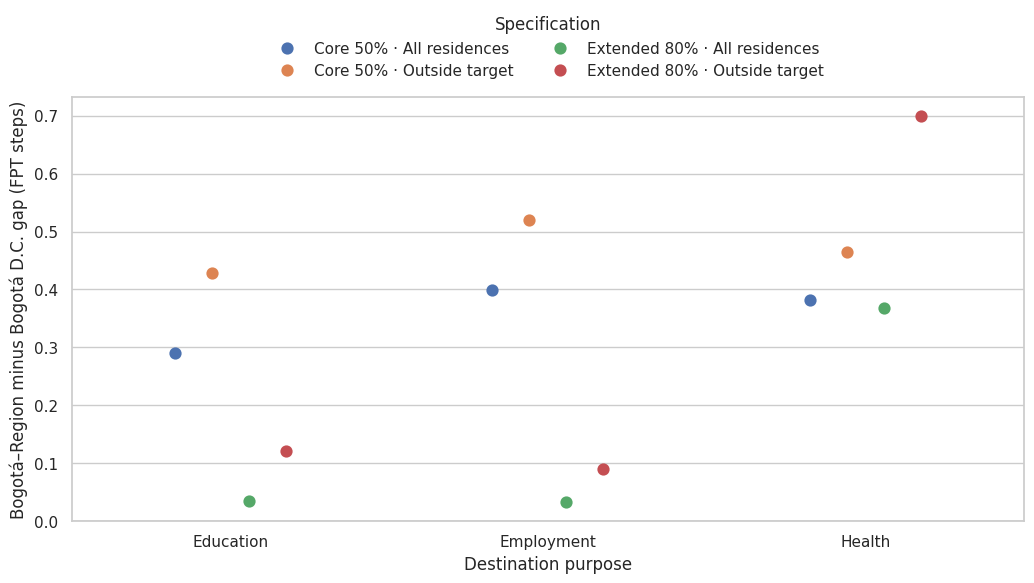

,purpose_group,stored_nodes,reconstructed_nodes,sets_identical
0,employment,24,24,True
1,education,24,24,True
2,health,17,17,True


,result
gate10_dependency_valid,True
gate12_dependency_valid,True
district_kernel_row_stochastic,True
district_core_targets_reproduced,True
district_primary_results_reproduced,True
all_four_specifications_complete,True
all_rows_unique,True
all_outputs_finite,True
district_decomposition_closed,True
gate_21_passed,True


Maximum primary replication error: 8.881784197001252e-16
Gate 21: APPROVED
Persistent copy: /content/drive/MyDrive/colombia-stochastic-access-data/bogota_em2023/results/gate21


In [8]:
sns.set_theme(style="whitegrid", context="notebook")
plot = paired.copy()
plot["specification"] = (
    plot["target_definition"].map({
        "core_50": "Core 50%",
        "extended_80": "Extended 80%",
    })
    + " · "
    + plot["conditioning"].map({
        "outside_target": "Outside target",
        "all_residences": "All residences",
    })
)
purpose_labels = {
    "employment": "Employment",
    "education": "Education",
    "health": "Health",
}
plot["purpose"] = plot["purpose_group"].map(purpose_labels)

fig, axis = plt.subplots(figsize=(10.5, 6.0))
sns.pointplot(
    data=plot,
    x="purpose",
    y="region_minus_district__female_minus_male_total",
    hue="specification",
    dodge=0.35,
    markers="o",
    linestyles="none",
    errorbar=None,
    ax=axis,
)
axis.axhline(0, color="black", linewidth=0.8)
axis.set(
    xlabel="Destination purpose",
    ylabel="Bogotá–Region minus Bogotá D.C. gap (FPT steps)",
)
axis.legend(
    title="Specification",
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
)
fig.tight_layout()
fig.savefig(
    OUT / "figure_paired_scope_specification_grid.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

stored_core = pd.read_csv(
    paths["city_core_targets"], dtype={"utam": "string"}
)
stored_core["utam"] = canonical_utam(stored_core["utam"])
new_core = city_targets[
    city_targets["target_definition"].eq("core_50")
]
target_match_rows = []
for purpose in PURPOSES:
    old_set = set(
        stored_core.loc[
            stored_core["purpose_group"].eq(purpose), "utam"
        ].dropna()
    )
    new_set = set(
        new_core.loc[
            new_core["purpose_group"].eq(purpose), "utam"
        ].dropna()
    )
    target_match_rows.append({
        "purpose_group": purpose,
        "stored_nodes": len(old_set),
        "reconstructed_nodes": len(new_set),
        "sets_identical": old_set == new_set,
    })
target_match = pd.DataFrame(target_match_rows)
target_match.to_csv(OUT / "district_core_target_replication.csv", index=False)

stored_city = pd.read_csv(paths["city_primary"])
primary_city = city_grid[
    city_grid["target_definition"].eq("core_50")
    & city_grid["conditioning"].eq("outside_target")
]
comparison = primary_city.merge(
    stored_city,
    on="purpose_group",
    suffixes=("_new", "_stored"),
)
replication_error = max(
    float(
        (
            comparison[f"{effect}_new"]
            - comparison[f"{effect}_stored"]
        ).abs().max()
    )
    for effect in EFFECTS
)

technical_checks = {
    "gate10_dependency_valid": True,
    "gate12_dependency_valid": True,
    "district_kernel_row_stochastic": bool(
        np.allclose(P0.sum(axis=1), 1.0, atol=1e-10)
    ),
    "district_core_targets_reproduced": bool(
        target_match["sets_identical"].all()
    ),
    "district_primary_results_reproduced": bool(
        replication_error <= 1e-9
    ),
    "all_four_specifications_complete": bool(
        len(paired)
        == len(PURPOSES)
        * len(TARGET_DEFINITIONS)
        * len(CONDITIONING_MODES)
    ),
    "all_rows_unique": bool(
        not paired.duplicated([
            "purpose_group", "target_definition", "conditioning"
        ]).any()
    ),
    "all_outputs_finite": bool(
        np.isfinite(
            paired.select_dtypes(include="number").to_numpy()
        ).all()
    ),
    "district_decomposition_closed": bool(
        city_grid["closure_error"].abs().max() <= 1e-10
    ),
}
technical_checks["gate_21_passed"] = bool(all(technical_checks.values()))

diagnostics = {
    "all_absolute_scope_contrasts_positive": bool(
        paired[
            "region_minus_district__female_minus_male_total"
        ].gt(0).all()
    ),
    "all_kernel_scope_contrasts_positive": bool(
        paired[
            "region_minus_district__kernel_contribution"
        ].gt(0).all()
    ),
    "all_relative_scope_contrasts_positive": bool(
        paired["region_minus_district__relative_gap"].gt(0).all()
    ),
}

report = {
    "generated_utc": datetime.now(timezone.utc).isoformat(),
    "purpose": (
        "paired point-estimate sensitivity of metropolitan amplification "
        "to target-set and residential-conditioning choices"
    ),
    "reference_scheme": "full_population",
    "target_definitions": list(TARGET_DEFINITIONS),
    "conditioning_modes": list(CONDITIONING_MODES),
    "regularization_tau": PRIMARY_TAU,
    "inference_boundary": (
        "This gate is a point-estimate sensitivity analysis. "
        "Primary simultaneous intervals must not be transferred to "
        "alternative specifications."
    ),
    "maximum_primary_replication_error": replication_error,
    "technical_gate": technical_checks,
    "diagnostics": diagnostics,
    "ranges": json.loads(summary.to_json(orient="records")),
    "gate": {"gate_21_passed": technical_checks["gate_21_passed"]},
}
(OUT / "gate_21.json").write_text(
    json.dumps(report, ensure_ascii=False, indent=2, allow_nan=False),
    encoding="utf-8",
)
pd.Series({**technical_checks, **diagnostics}, name="result").to_csv(
    OUT / "gate_21_checks.csv"
)
display(target_match)
display(pd.Series({**technical_checks, **diagnostics}, name="result"))
print("Maximum primary replication error:", replication_error)

if not technical_checks["gate_21_passed"]:
    raise RuntimeError("Gate 21 failed; inspect gate_21_checks.csv")

persistent = DRIVE_BASE / "results/gate21"
persistent.mkdir(parents=True, exist_ok=True)
for artifact in OUT.iterdir():
    if artifact.is_file():
        shutil.copy2(artifact, persistent / artifact.name)

print("Gate 21: APPROVED")
print("Persistent copy:", persistent)
